<a href="https://colab.research.google.com/github/minjeon99/ESAA-10th-OB/blob/Week11/w11_fri_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**4. 합성곱 신경망(CNN)**

## **01 합성곱 신경망**
- **합성곱 신경망(CNN: Convolutional Neural Network)**: 데이터가 가진 특징들의 패턴을 학습하는 알고리즘
  - 컴퓨터 비전 분야에서 많이 사용
    - 이미지 분류(Image Classification)

      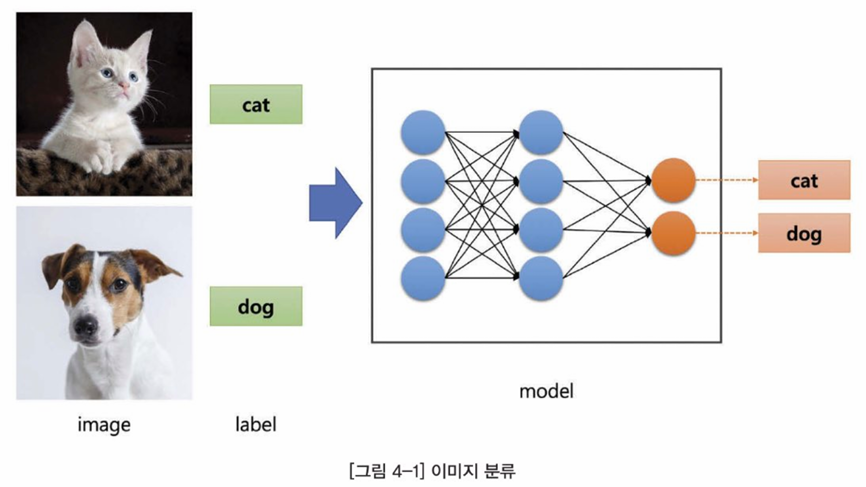
    - 객체 탐지(Object Detection)

      - 객체의 위치는 일반적으로 이미지의 좌표 값으로 표현 ➡️ 회귀

      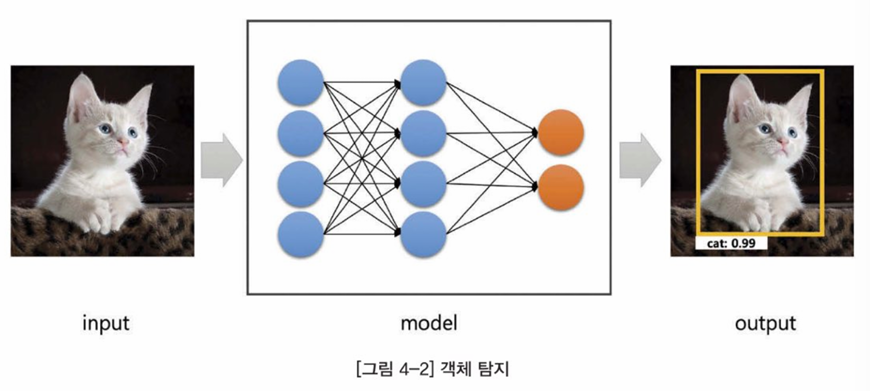
    - 스타일 전이(Style Transfer)


### 1. 이미지 표현
이미지(영상)를 컴퓨터가 이해할 수 있게 하려면 숫자로 표현해야 함. 이번에 다룰 이미지들은 모두 숫자 데이터로 기록돼 있음.

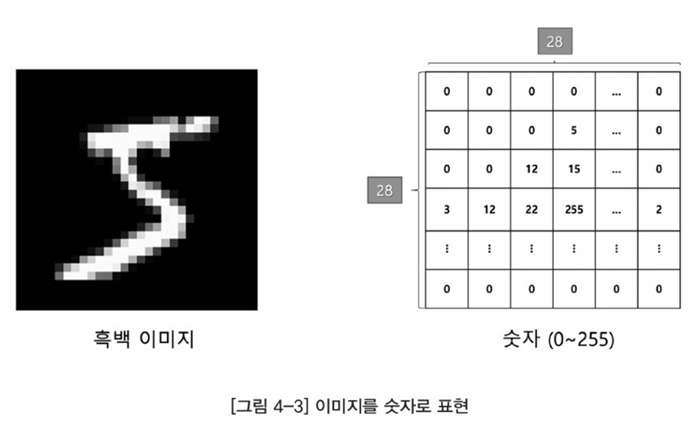
- 0~255 사이의 숫자로 각 픽셀의 화소 값 표현
  - 0: 검은 색, 255: 흰색

  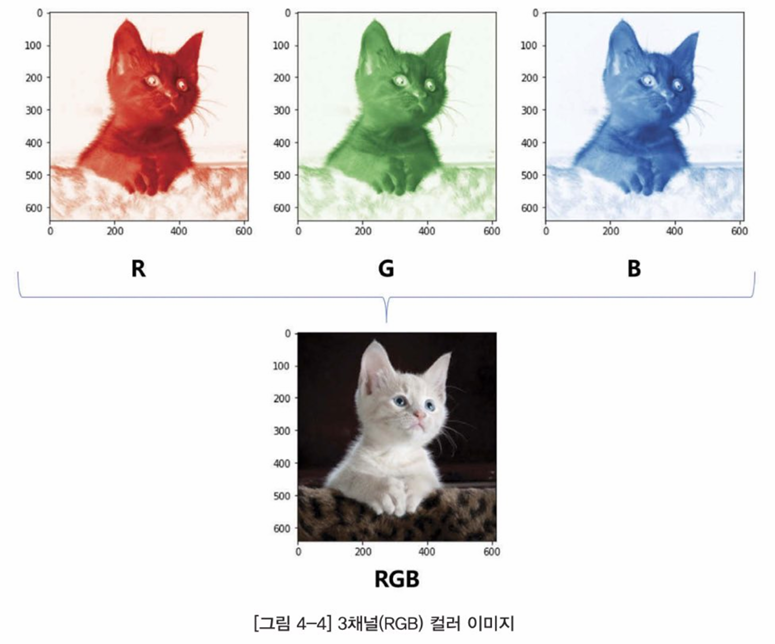
  - 컬러 이미지: R(빨강), G(초록), B(파랑) 채널로 구성된 3장의 이미지를 겹쳐서 표현

### 2. 합성곱(Convolution)
- 합성곱 연산: 입력 이미지에 대하여 일반적으로 정방형 크기를 가지는 커널(kernel)을 사용하여, 입력 이미지에 대한 특성을 추출하는 방법
- 특성맵(feature map): 합성곱 연산을 통해서 추출된 이미지
  - 추출된 특성맵을 딥러닝 모델 학습에 사용하면 훨씬 좋은 성능을 보임

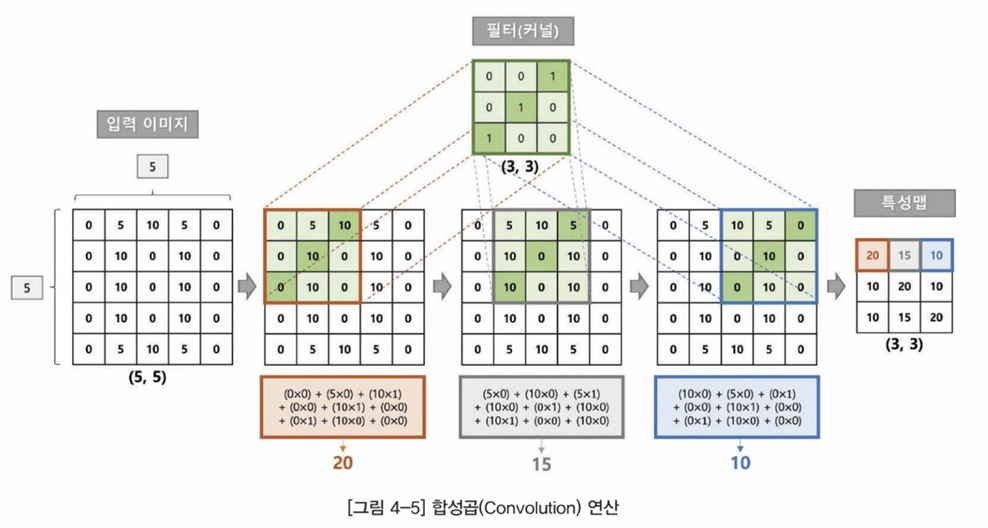
- 입력 이미지 크기: (세로, 가로) 순서로 shape 출력
- 입력 이미지의 좌측 상단부터 커널과 같은 크기를 갖도록 입력 이미지의 일부분에 커널이 겹치도록 투영
- 커널 사이즈가 (3,3)인 경우 9개의 가중치(weight), 오차 역전파(back propagation) 시 커널 가중치 업데이트
- 합성곱 신경망이 이미지 특성 추출에 효율적인 이유

  ➡️ 공유 가중치(shared weights)
  - 커널의 gradient 계산 시 9개에 대해서만 업데이트 ⏩ 완전 연결층 사용할 때보다 훨씬 적은 연산량

### 3. 채널(channel)
- **채널**: 입력 이미지를 구성하는 2차원 배열의 개수
  - 흑백 이미지 → 채널 개수 = 1인 단일 채널
  - 컬러 이미지 → 채널 대수 3개
    - shape: (세로, 가로, 3)
- 입력 이미지가 여러 개의 채널을 갖는 경우 합성곱 연산 수행시 특성맵 생성 과정# 3. 채널(channel)
- **채널**: 입력 이미지를 구성하는 2차원 배열의 개수
  - 흑백 이미지 → 채널 개수 = 1인 단일 채널
    - 컬러 이미지 → 채널 대수 3개
        - shape: (세로, 가로, 3)

  📍 다중 채널의 합성곱 연산

  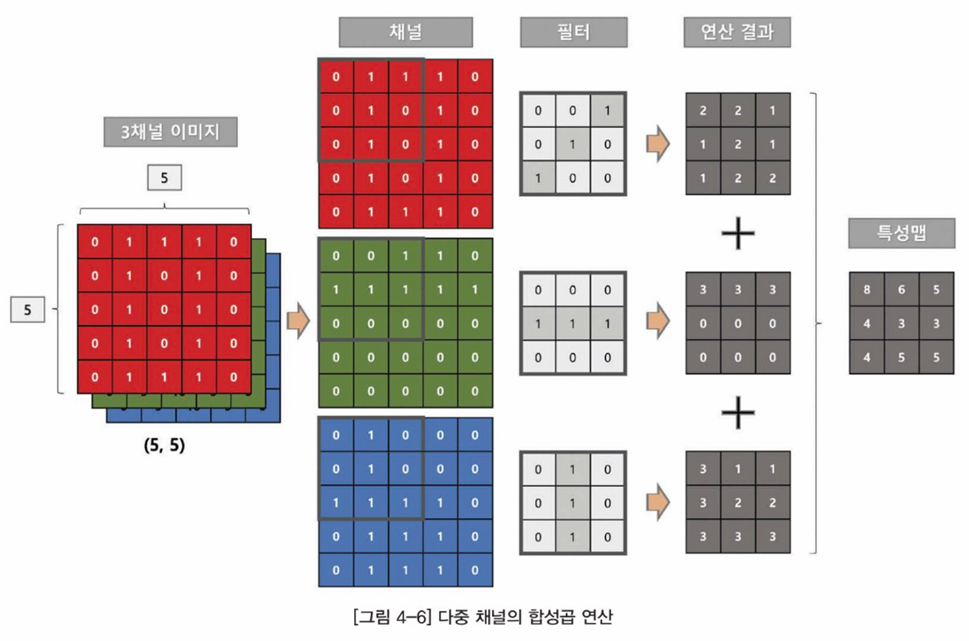
  - 입력 이미지의 채널 개수만큼 커널 생성
  - 채널마다 하나씩 커널 적용하여 합성곱 연산 수행
  
  → 입력 이미지의 채널 개수만큼 합성곱 연산된 결과 생성

  → element-wise 덧셈 연산으로 모두 더해주면 최종 특성맵 생성
- 출력 필터 개수에 따른 파라미터 개수
  예) 출력 필터: 20개

  ➡️ 입력 채널 개수(3) * 출력 필터 개수(20) = 커널 60개
  - 1개 커널 사이즈: (3,3) ➡️ ( 3 * 3 * 입력 채널 * 출력 필터 ) = 540개
  - bias가 출력 필터 개수만큼 추가 ➡️ 20개 추가

  ⏩ 총 560개

### 4. 스트라이드(stride)
- **스트라이드(stride)**: 합성곱 연산 수행시 이동하는 간격
  - `스트라이드=1` → 우측으로 1픽셀씩 이동
  - `스트라이드=2` → 우측으로 2픽셀씩 이동 ➡️ 특성맵 크기 $\frac{1}{2}$
- 텐서플로 케라스의 `Conv2D` 레이어 `strides` 매개변수에 지정

  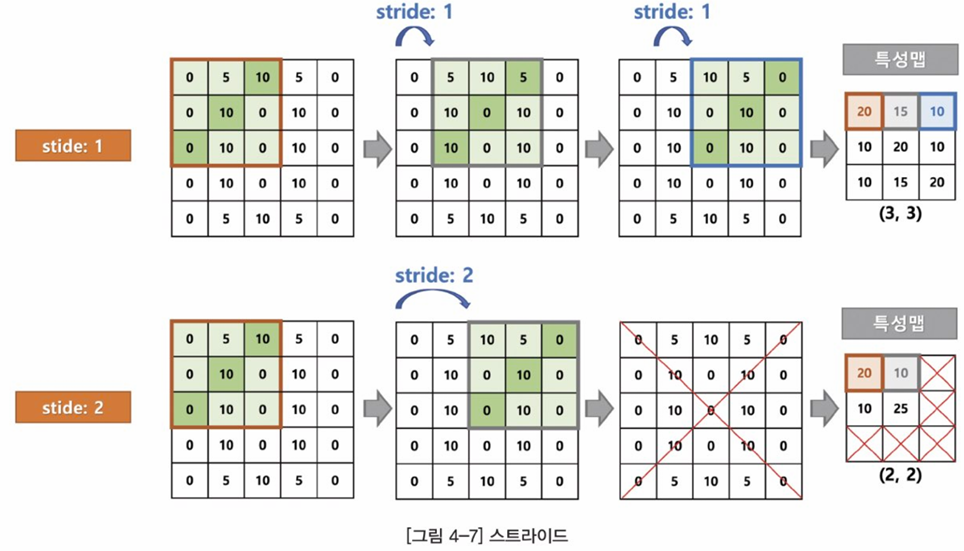

### 5. 패딩(Padding)
- 패딩(padding): 스추출된 특성맵의 크기가 입력 이미지 대비 줄어들지 않도록 설정
  - 일반적으로 zero-padding → 입력 이미지의 가장 자리에 패딩 값 0으로 채운 후 추출
- 텐서플로 케라스의 `Conv2D` 레이어에서 `padding='same'` 설정 ➡️ zero-padding
  - 기본값: `padding='valid'`

  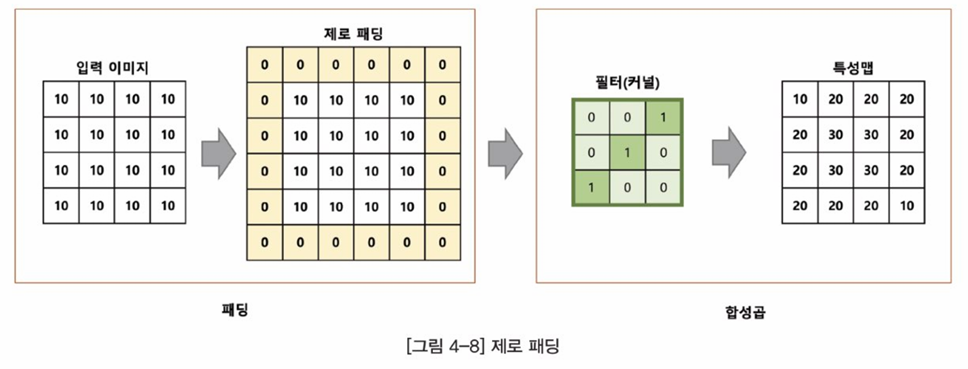

### 6. 특성맵(feature map) 사이즈
- 패딩과 스트라이드 적용하고, 입력 데이터와 필터의 크기가 주어졌을 때 출력 데이터의 크기

  (Output Height, Output Width) = ($\frac{Image \space Height+2P-Kernel\space Height}{S}+1$, $\frac{Image \space Width+2P-Kernel\space Width}{S}+1$)

### 7. 풀링(pooling)
- 풀링(pooling) 레이어: 추출된 특성맵에 대해 다운 샘플링하여 이미지의 크기를 축소하는 레이어
  - 이미지 축소를 통해 연산량 감소, 과대적합(overfitting) 방지
1. 최대 풀링(max pooling): 큰 값이 다른 특징들을 대표한다는 개념으로 도입 ➡️ 좋은 성능을 발휘하며 주로 사용됨
2. 평균 풀링(average pooling)
- 풀링 레이어도 스트라이드 값을 가짐
  
  예) `stride=2` → 2칸씩 건너뛰면서 풀링 수행
  - kernel: 2x2, stride: 2 ➡️ 출력 이미지: 가로 $\frac{1}{2}$, 세로 $\frac{1}{2}$로 감소 → 입력 이미지 대비 $\frac{1}{4}$ 크기

## **02 간단한 모델 생성**
- mnist 손글씨 데이터셋으로 간단한 구조의 합성곱 신경망 모델 만들기

### 1. 데이터 로드 및 전처리

In [1]:
# tensorflow 모듈 import
import tensorflow as tf

In [2]:
# mnist 손글씨 이미지 데이터 로드
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_valid, y_valid) = mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)

11490434/11490434 [==============================] - 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


- 훈련 데이터: 60,000개
- 검증 데이터: 10,000개
- 가로, 세로 28픽셀인 손글씨 이미지와 숫자 레이블(정답)

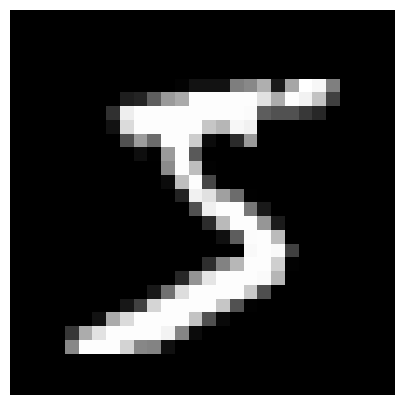

In [3]:
# 샘플 이미지 출력
import matplotlib.pyplot as plt

def plot_image(data, idx):
  plt.figure(figsize=(5,5))
  plt.imshow(data[idx], cmap='gray')
  plt.axis("off")
  plt.show()

plot_image(x_train, 0)

In [4]:
print(x_train.min(), x_train.max())
print(x_valid.min(), x_valid.max())

0 255
0 255


In [5]:
# 정규화(Normalization)
x_train = x_train/255.0
x_valid = x_valid/255.0

print(x_train.min(), x_train.max())
print(x_valid.min(), x_valid.max())

0.0 1.0
0.0 1.0


- 딥러닝 모델의 안정적인 학습을 위해 입력 이미지 픽셀 값을 정규화 변환
  - 이미지 픽셀 값을 최대값 255로 나누어서 0~1 범위로 스케일 정규화

In [6]:
# 채널 추가
print(x_train.shape, x_valid.shape)

x_train_in = x_train[..., tf.newaxis]
x_valid_in = x_valid[..., tf.newaxis]

print(x_train_in.shape, x_valid_in.shape)

(60000, 28, 28) (10000, 28, 28)
(60000, 28, 28, 1) (10000, 28, 28, 1)


- mnist 데이터셋은 색상을 나타내는 채널이 1개인 모노 컬러 이미지
  
  ➡️ CNN 모델에 주입하기 위해서 색상을 나타내는 채널 추가
- `[ ]` 안에서 채널을 추가하고자 하는 위치에 `tf.newaxis` 작성
  - 가장 마지막 축에 채널을 추가하기 위해 `[..., tf.newaxis]`
    - `...` : Python에서 가변 인자를 나타내는 특별한 구문

###2. Sequential API로 모델 생성 및 학습
✔️ `Sequential API`를 사용하여 합성곱 레이어 1개, 풀링 레이어 1개를 적용하는 간단한 모델 만들기
  - 최종 분류기로 Dense 레이어를 적용하기 위해 Flatten 층을 추가하여 1차원 배열로 펼치기
  - 합성곱: Conv2D를 사용하고 (3,3) 크기의 서로 다른 32가지 종류의 커널 적용
    - 활성화 함수: ReLU
    - name 속성에 레이어 이름을 'conv'로 지정
  - 풀링 레이어: (2,2) 크기로 max pooling 적용
  - 최종 분류기: 정답 레이블이 0~9까지 10개의 값을 가지므로 노드 개수 10개
    - 활성화 함수: softmax

  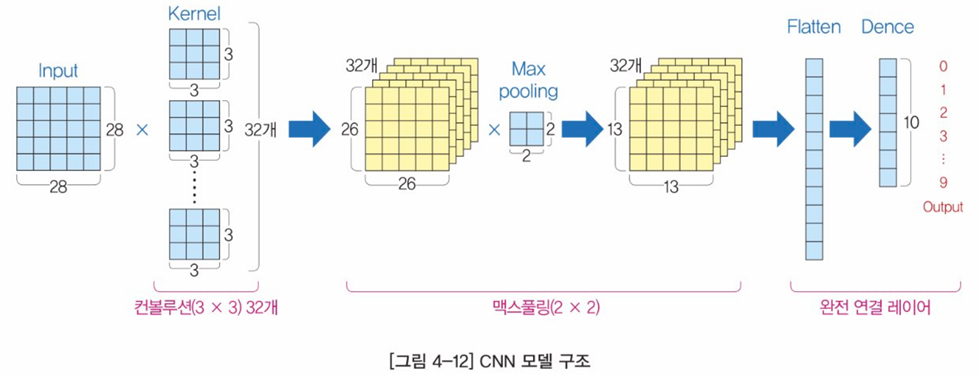

In [7]:
# Sequential API를 사용해 샘플 모델 생성
model = tf.keras.Sequential([
    # Convolution 적용(32 filters)
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), name='conv'),
    # Max Pooling 적용
    tf.keras.layers.MaxPooling2D((2,2), name='pool'),
    # Classifier 출력층
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation='softmax')
])

- optimizer, loss function, metrics 설정 후 컴파일하면 모델 인스턴스 생성
- `fit()` 메소드에 훈련 셋, 검증 셋 주입
- `epoch=10` 지정

In [8]:
# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
history = model.fit(x_train_in, y_train, validation_data=(x_valid_in, y_valid), epochs=10)

Epoch 1/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.2244 - accuracy: 0.9352 - val_loss: 0.0942 - val_accuracy: 0.9727
Epoch 2/10
1875/1875 [==============================] - 8s 5ms/step - loss: 0.0852 - accuracy: 0.9753 - val_loss: 0.0684 - val_accuracy: 0.9779
Epoch 3/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0643 - accuracy: 0.9812 - val_loss: 0.0577 - val_accuracy: 0.9803
Epoch 4/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0520 - accuracy: 0.9847 - val_loss: 0.0542 - val_accuracy: 0.9816
Epoch 5/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0434 - accuracy: 0.9870 - val_loss: 0.0514 - val_accuracy: 0.9840
Epoch 6/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0371 - accuracy: 0.9889 - val_loss: 0.0578 - val_accuracy: 0.9813
Epoch 7/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0309 - accuracy: 0.9907 - val_loss: 0.0531 - val_accuracy

- 코드를 실행하면 모델이 학습되면서 epoch당 손실과 평가 결과 출력
- 두 번째 epoch를 마친 상태에서도 훈련 셋과 검증 셋 모두 97%에 가까운 정확도

In [9]:
model.evaluate(x_valid_in, y_valid)

313/313 [==============================] - 1s 2ms/step - loss: 0.0593 - accuracy: 0.9828


[0.05925939977169037, 0.9828000068664551]

- evaluate() 메소드를 모델 인스턴스에 적용하면 모델의 학습된 가중치를 사용하여 손실과 평가지표를 계산
- 검증 셋에 대해서 약 98%의 정확도를 보임

- 모델 훈련 단계에서 훈련 결과를 history 객체에 저장해둠
- 10 epoch 동안 예측 오차와 정확도를 그래프로 그리는 함수 정의

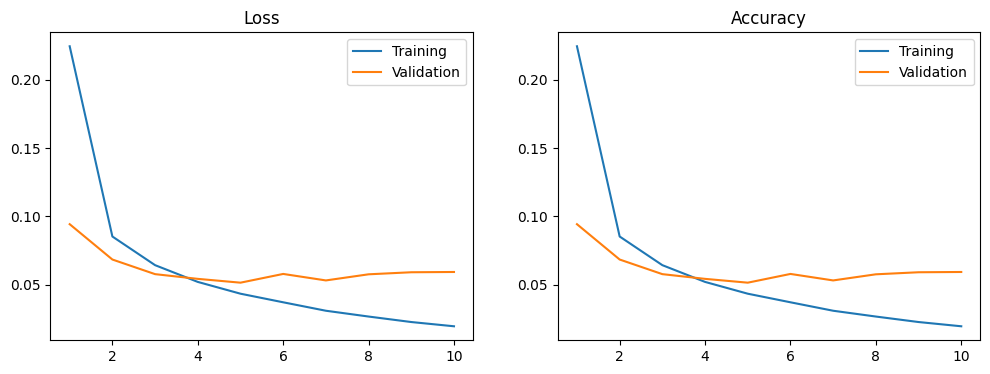

In [10]:
def plot_loss_acc(history, epoch):
  loss, val_loss = history.history['loss'], history.history['val_loss']
  acc, val_acc = history.history['accuracy'], history.history['val_accuracy']

  fig, axes = plt.subplots(1,2,figsize=(12,4))

  axes[0].plot(range(1, epoch+1), loss, label='Training')
  axes[0].plot(range(1, epoch+1), val_loss, label='Validation')
  axes[0].legend(loc='best')
  axes[0].set_title('Loss')

  axes[1].plot(range(1, epoch+1), loss, label='Training')
  axes[1].plot(range(1, epoch+1), val_loss, label='Validation')
  axes[1].legend(loc='best')
  axes[1].set_title('Accuracy')

  plt.show()

plot_loss_acc(history, 10)

- 훈련 셋에 대한 손실은 계속 줄어드는데, 검증 셋의 손실은 어느 수준에서 더 이상 낮아지지 않음
- 4 epoch 이후부터는 모델이 과대적합으로 진행

### 3. 모델 구조 파악
모델 인스턴스에 `summary()` 메소드 적용 → 모델 구조를 요약
- 각 레이어의 이름, 출력 텐서의 형태, 각 레이어를 구성하는 파라미터(가중치) 개수

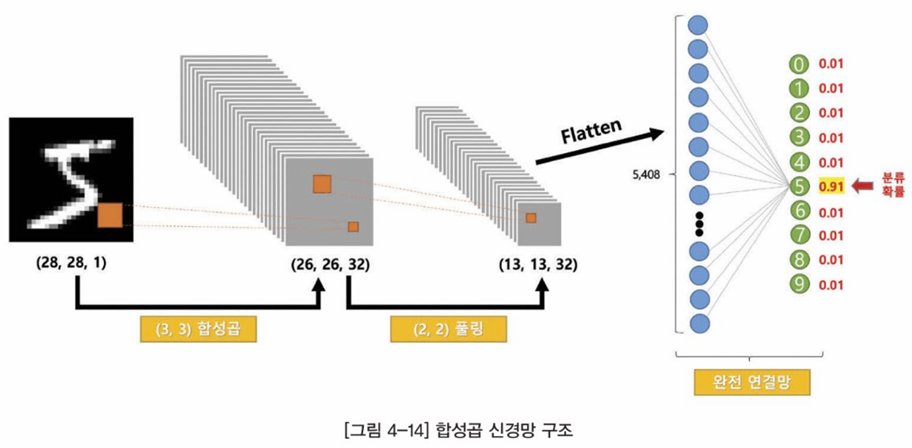

In [11]:
# 모델 구조
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv (Conv2D)               (None, 26, 26, 32)        320       
                                                                 
 pool (MaxPooling2D)         (None, 13, 13, 32)        0         
                                                                 
 flatten (Flatten)           (None, 5408)              0         
                                                                 
 dense (Dense)               (None, 10)                54090     
                                                                 
Total params: 54410 (212.54 KB)
Trainable params: 54410 (212.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


- (2,2) 크기의 풀링 레이어를 적용 ➡️ 이미지 크기가 $\frac{1}{2}$로 감소 → (13,13,32) 텐서로 변환
- Flatten 층에서 3차원 텐서를 1차원 텐서로 펼치기 ➡️ 5,408(=13x13x32)개 원소를 갖는 1차원 벡터
- 출력 노드 10개인 Dense 레이어로 보내면 최종 분류 값을 예측해 출력

In [13]:
# 입력 텐서 형태
model.input

<KerasTensor: shape=(None, 28, 28, 1) dtype=float32 (created by layer 'conv_input')>

- 생성된 모델 인스턴스의 input 속성으로부터 입력 레이어의 텐서 추출
  - (None, 28, 28, 1) 형태 ➡️ (axis=0)의 None 값은 배치 크기가 들어오는 위치 = 어느 값이든 가능

In [14]:
# 출력 텐서 형태
model.output

<KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'dense')>

- 모델의 출력 텐서 ➡️ 10개의 노드를 갖는 1차원 벡터 형태

In [15]:
# 레이어
model.layers

- 모델을 구성하는 레이어 추출
  - 리스트 형태로 레이어 객체를 담아서 출력

In [16]:
# 첫 번째 레이어
model.layers[0]

- 리스트 인덱싱을 적용해서 첫 번째 레이어 선택

In [17]:
# 첫 번째 레이어 입력
model.layers[0].input

<KerasTensor: shape=(None, 28, 28, 1) dtype=float32 (created by layer 'conv_input')>

- 각 레이어에 입력되는 텐서를 따로 선택하는 것도 가능
  - Conv2D 레이어에는 모델의 입력 데이터가 그대로 들어가기 때문에 (None, 28, 28, 1) 형태

In [18]:
# 첫 번째 레이어 출력
model.layers[0].output

<KerasTensor: shape=(None, 26, 26, 32) dtype=float32 (created by layer 'conv')>

- 각 레이어에서 출력되는 텐서 확인
  - Conv2D 레이어를 거치면 픽셀 사이즈가 2씩 줄어들고 채널 개수가 32개로 늘어남 ➡️ (None, 26, 26, 32)

In [19]:
# 첫 번째 레이어 가중치
model.layers[0].weights

[<tf.Variable 'conv/kernel:0' shape=(3, 3, 1, 32) dtype=float32, numpy=
 array([[[[ 0.38243878,  0.03743106,  0.3583059 ,  1.0530883 ,
            0.26135173, -0.00183384, -0.22208501,  0.26747957,
           -0.29820615, -0.67760575, -1.1403328 ,  0.2695761 ,
            0.32303834, -0.04169647, -0.14132506, -0.30845144,
           -0.21700871,  0.20509183, -1.4167293 ,  0.6024587 ,
           -0.27996716, -0.13200922, -0.04163545,  0.07229802,
            0.22907436, -0.5967714 ,  0.15111774, -1.131822  ,
           -0.04821786, -0.4444445 , -0.07563282, -0.5641616 ]],
 
         [[ 0.73301405,  0.34514126,  0.30781305, -1.1805491 ,
            0.34837347,  0.38394547,  0.15023753,  0.33796528,
           -0.35565004, -0.59502715, -0.80085343, -0.00766274,
           -0.3259536 ,  0.4175738 ,  0.22288536,  0.346843  ,
           -0.4012276 ,  0.13788709, -1.0455571 ,  0.12563337,
            0.02113067, -0.46686813,  0.08715963,  0.4838216 ,
           -0.13172045, -0.05476883,  0.26

- 각 레이어의 가중치 행렬 추출
  - `tf.Variable`(텐서플로 변수)는 가중치처럼 모델 학습 과정에 값이 업데이트되는 경우 사용
  - 변수 1 `conv/kernel:0`: 커널(합성곱 필터) 행렬의 가중치
  - 변수 2 `conv/bias:0`: 각 커널의 상수항(bias)
- 커널 가중치의 shape: (3,3,1,32)
  - (3,3): 필터 크기
  - (1): 입력층의 채널 개수
  - (32): 출력층의 채널 개수
- bias 가중치의 shape: (32,) = 출력층의 채널 수

In [20]:
# 첫 번째 레이어 커널 가중치
model.layers[0].kernel

<tf.Variable 'conv/kernel:0' shape=(3, 3, 1, 32) dtype=float32, numpy=
array([[[[ 0.38243878,  0.03743106,  0.3583059 ,  1.0530883 ,
           0.26135173, -0.00183384, -0.22208501,  0.26747957,
          -0.29820615, -0.67760575, -1.1403328 ,  0.2695761 ,
           0.32303834, -0.04169647, -0.14132506, -0.30845144,
          -0.21700871,  0.20509183, -1.4167293 ,  0.6024587 ,
          -0.27996716, -0.13200922, -0.04163545,  0.07229802,
           0.22907436, -0.5967714 ,  0.15111774, -1.131822  ,
          -0.04821786, -0.4444445 , -0.07563282, -0.5641616 ]],

        [[ 0.73301405,  0.34514126,  0.30781305, -1.1805491 ,
           0.34837347,  0.38394547,  0.15023753,  0.33796528,
          -0.35565004, -0.59502715, -0.80085343, -0.00766274,
          -0.3259536 ,  0.4175738 ,  0.22288536,  0.346843  ,
          -0.4012276 ,  0.13788709, -1.0455571 ,  0.12563337,
           0.02113067, -0.46686813,  0.08715963,  0.4838216 ,
          -0.13172045, -0.05476883,  0.26184994, -0.030213

In [21]:
# 첫 번째 레이어 bias 가중치
model.layers[0].bias

<tf.Variable 'conv/bias:0' shape=(32,) dtype=float32, numpy=
array([ 0.03988936, -0.1812824 , -0.27532157, -0.01574195, -0.3631177 ,
       -0.02835012, -0.33998764, -0.26781344, -0.36770573, -0.03074986,
        0.08321309, -0.31195387, -0.28409228, -0.3003921 , -0.22894688,
       -0.25855532, -0.00785587, -0.3059107 , -0.03144322,  0.15425494,
       -0.35431743, -0.00936328, -0.01733886, -0.05735587, -0.27329287,
       -0.25306955, -0.3305647 , -0.08408545, -0.2312758 , -0.1746613 ,
       -0.16361056, -0.07398368], dtype=float32)>

In [26]:
# 레이어 이름 사용하여 레이어 선택
model.get_layer('conv')

- 레이어 이름(`name` 속성)을 사용하여 레이어 선택

In [28]:
# 샘플 이미지의 레이어별 출력을 리스트에 추가(첫 번째, 두 번째 레이어)
activator = tf.keras.Model(inputs=model.input, outputs=[layer.output for layer in model.layers[:2]])

activations = activator.predict(x_train_in[0][tf.newaxis, ...])

len(activations)

1/1 [==============================] - 0s 43ms/step


2

In [29]:
# 첫 번째 레이어(conv) 출력층
conv_activation = activations[0]
conv_activation.shape

(1, 26, 26, 32)

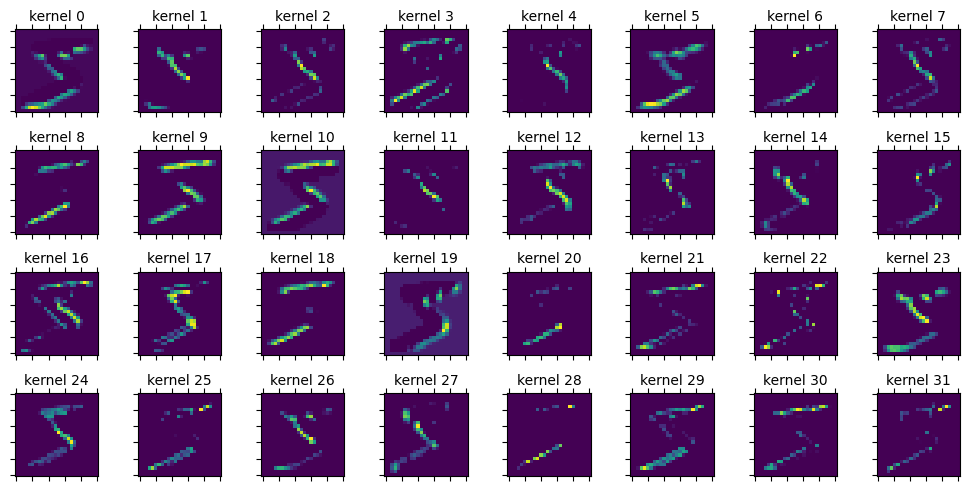

In [30]:
# Convolution 시각화
fig, axes = plt.subplots(4, 8)
fig.set_size_inches(10, 5)

for i in range(32):
    axes[i//8, i%8].matshow(conv_activation[0, :, :, i], cmap='viridis')
    axes[i//8, i%8].set_title('kernel %s'%str(i), fontsize=10)
    plt.setp( axes[i//8, i%8].get_xticklabels(), visible=False)
    plt.setp( axes[i//8, i%8].get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()

In [31]:
# 두 번째 레이어(pool) 출력층
pooling_activation = activations[1]
print(pooling_activation.shape)

(1, 13, 13, 32)


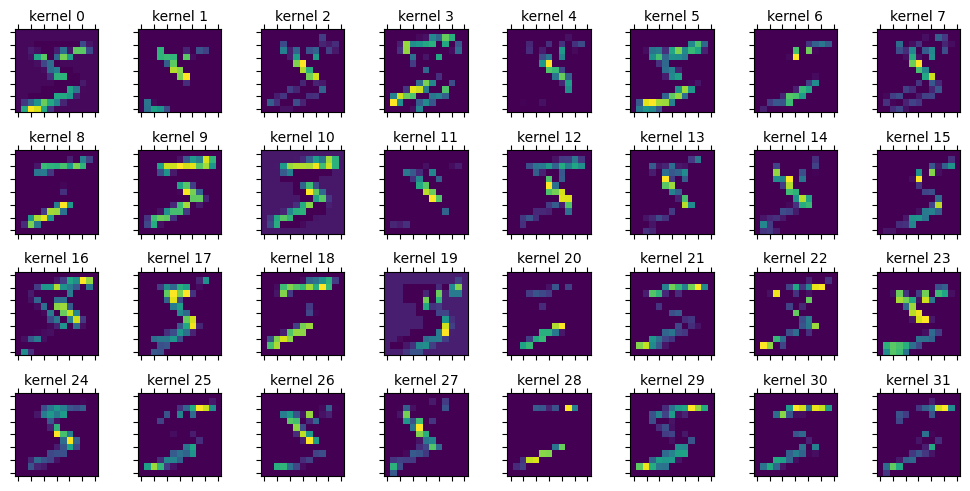

In [32]:
# 시각화
fig, axes = plt.subplots(4, 8)
fig.set_size_inches(10, 5)

for i in range(32):
    axes[i//8, i%8].matshow(pooling_activation[0, :, :, i], cmap='viridis')
    axes[i//8, i%8].set_title('kernel %s'%str(i), fontsize=10)
    plt.setp( axes[i//8, i%8].get_xticklabels(), visible=False)
    plt.setp( axes[i//8, i%8].get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()

## **03 복잡한 모델 생성**
텐서플로 케라스의 `Functional API` 사용 ➡️ `Sequential API`로 구현할 수 없는 복잡한 구조의 모델 정의
- 각 레이어 기준 입력이 2개 이상이거나 출력이 2개 이상인 모델
- 중간에 있는 레이어들을 건너뛰고 뒤쪽에 있는 레이어로 출력 텐서를 전달하는 방식으로 직접 연결

### 1. 데이터셋 준비

In [3]:
import tensorflow as tf
import numpy as np

In [4]:
# MNIST 손글씨 이미지 데이터 로드
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_valid, y_valid) = mnist.load_data()

print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [5]:
# 새로운 출력값 배열을 생성 (홀수: 1, 짝수: 0)
y_train_odd = []
for y in y_train:
    if y % 2==0:
        y_train_odd.append(0)
    else:
        y_train_odd.append(1)

y_train_odd = np.array(y_train_odd)
y_train_odd.shape

(60000,)

In [6]:
print(y_train[:10])
print(y_train_odd[:10])

[5 0 4 1 9 2 1 3 1 4]
[1 0 0 1 1 0 1 1 1 0]


In [7]:
# Validation 데이터셋 처리
y_valid_odd = []
for y in y_valid:
    if y % 2==0:
        y_valid_odd.append(0)
    else:
        y_valid_odd.append(1)

y_valid_odd = np.array(y_valid_odd)
y_valid_odd.shape

(10000,)

In [8]:
# 정규화(Normalization)
x_train = x_train / 255.0
x_valid = x_valid / 255.0

# 채널 추가
x_train_in = tf.expand_dims(x_train, -1)
x_valid_in = tf.expand_dims(x_valid, -1)

print(x_train_in.shape, x_valid_in.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


### 2. Functional API로 다중 입력, 다중 출력 레이어 생성

In [9]:
# Functional API를 사용하여 모델 생성

inputs = tf.keras.layers.Input(shape=(28, 28, 1))

conv = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
pool = tf.keras.layers.MaxPooling2D((2, 2))(conv)
flat = tf.keras.layers.Flatten()(pool)

flat_inputs = tf.keras.layers.Flatten()(inputs)
concat = tf.keras.layers.Concatenate()([flat, flat_inputs])
outputs = tf.keras.layers.Dense(10, activation='softmax')(concat)

model = tf.keras.models.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 28, 28, 1)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 26, 26, 32)           320       ['input_1[0][0]']             
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)           0         ['conv2d[0][0]']              
 D)                                                                                               
                                                                                                  
 flatten (Flatten)           (None, 5408)                 0         ['max_pooling2d[0][0]']   

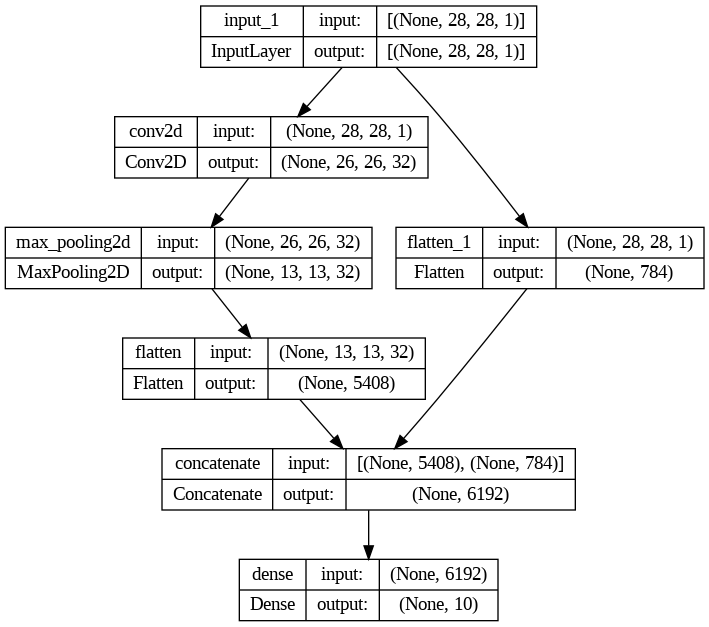

In [10]:
# 모델 구조 출력 및 이미지 파일로 저장
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True, to_file='functional_cnn.png')

In [11]:
# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
history = model.fit(x_train_in, y_train,
                    validation_data=(x_valid_in, y_valid),
                    epochs=10)

# 모델 성능
val_loss, val_acc = model.evaluate(x_valid_in, y_valid)
print(val_loss, val_acc)

Epoch 1/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1992 - accuracy: 0.9428 - val_loss: 0.0820 - val_accuracy: 0.9756
Epoch 2/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0758 - accuracy: 0.9781 - val_loss: 0.0673 - val_accuracy: 0.9774
Epoch 3/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0582 - accuracy: 0.9823 - val_loss: 0.0607 - val_accuracy: 0.9816
Epoch 4/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0488 - accuracy: 0.9851 - val_loss: 0.0705 - val_accuracy: 0.9768
Epoch 5/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0405 - accuracy: 0.9875 - val_loss: 0.0552 - val_accuracy: 0.9820
Epoch 6/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0343 - accuracy: 0.9896 - val_loss: 0.0507 - val_accuracy: 0.9840
Epoch 7/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0278 - accuracy: 0.9912 - val_loss: 0.0585 - val_acc

### 3. 다중 출력 분류 모델

In [12]:
# Functional API를 사용하여 모델 생성

inputs = tf.keras.layers.Input(shape=(28, 28, 1), name='inputs')

conv = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', name='conv2d_layer')(inputs)
pool = tf.keras.layers.MaxPooling2D((2, 2), name='maxpool_layer')(conv)
flat = tf.keras.layers.Flatten(name='flatten_layer')(pool)

flat_inputs = tf.keras.layers.Flatten()(inputs)
concat = tf.keras.layers.Concatenate()([flat, flat_inputs])
digit_outputs = tf.keras.layers.Dense(10, activation='softmax', name='digit_dense')(concat)

odd_outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='odd_dense')(flat_inputs)

model = tf.keras.models.Model(inputs=inputs, outputs=[digit_outputs, odd_outputs])

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 inputs (InputLayer)         [(None, 28, 28, 1)]          0         []                            
                                                                                                  
 conv2d_layer (Conv2D)       (None, 26, 26, 32)           320       ['inputs[0][0]']              
                                                                                                  
 maxpool_layer (MaxPooling2  (None, 13, 13, 32)           0         ['conv2d_layer[0][0]']        
 D)                                                                                               
                                                                                                  
 flatten_layer (Flatten)     (None, 5408)                 0         ['maxpool_layer[0][0]'] 

In [13]:
# 모델의 입력과 출력을 나타내는 텐서
print(model.input)
print(model.output)

KerasTensor(type_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='inputs'), name='inputs', description="created by layer 'inputs'")
[<KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'digit_dense')>, <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'odd_dense')>]


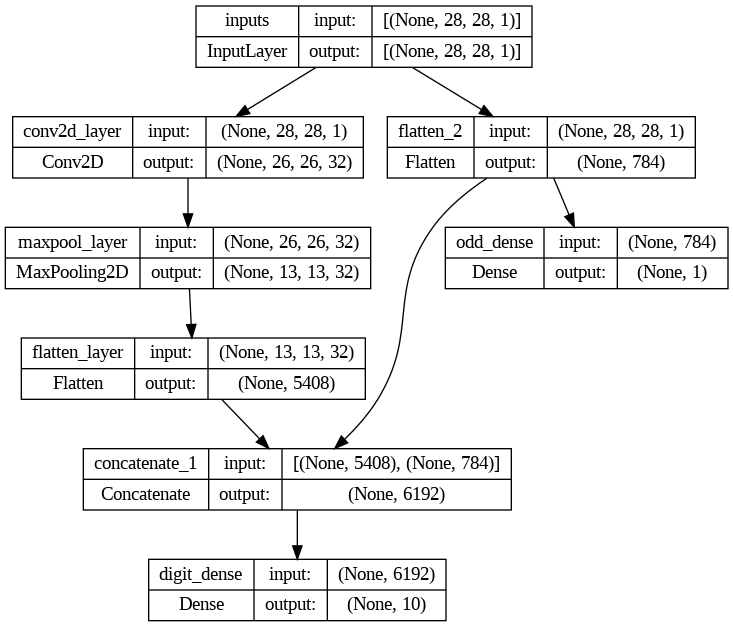

In [14]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file='multi_output_cnn.png')

In [15]:
# 모델 컴파일
model.compile(optimizer='adam',
              loss={'digit_dense': 'sparse_categorical_crossentropy', 'odd_dense': 'binary_crossentropy'},
              loss_weights={'digit_dense': 1, 'odd_dense': 0.5}, # loss = 1.0 *sparse_categorical_crossentropy + 0.5*binary_crossentropy
              metrics=['accuracy'])

# 모델 훈련
history = model.fit({'inputs': x_train_in}, {'digit_dense': y_train, 'odd_dense': y_train_odd},
                    validation_data=({'inputs': x_valid_in},  {'digit_dense': y_valid, 'odd_dense': y_valid_odd}),
                    epochs=10)

Epoch 1/10
1875/1875 [==============================] - 11s 6ms/step - loss: 0.3720 - digit_dense_loss: 0.2098 - odd_dense_loss: 0.3243 - digit_dense_accuracy: 0.9395 - odd_dense_accuracy: 0.8642 - val_loss: 0.2272 - val_digit_dense_loss: 0.0898 - val_odd_dense_loss: 0.2750 - val_digit_dense_accuracy: 0.9721 - val_odd_dense_accuracy: 0.8905
Epoch 2/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.2177 - digit_dense_loss: 0.0820 - odd_dense_loss: 0.2713 - digit_dense_accuracy: 0.9760 - odd_dense_accuracy: 0.8917 - val_loss: 0.2007 - val_digit_dense_loss: 0.0694 - val_odd_dense_loss: 0.2627 - val_digit_dense_accuracy: 0.9781 - val_odd_dense_accuracy: 0.8967
Epoch 3/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1921 - digit_dense_loss: 0.0608 - odd_dense_loss: 0.2626 - digit_dense_accuracy: 0.9818 - odd_dense_accuracy: 0.8955 - val_loss: 0.1870 - val_digit_dense_loss: 0.0572 - val_odd_dense_loss: 0.2595 - val_digit_dense_accuracy: 0.9800 - va

In [16]:
# 모델 성능
model.evaluate({'inputs': x_valid_in}, {'digit_dense': y_valid, 'odd_dense': y_valid_odd})

313/313 [==============================] - 1s 2ms/step - loss: 0.1843 - digit_dense_loss: 0.0559 - odd_dense_loss: 0.2569 - digit_dense_accuracy: 0.9835 - odd_dense_accuracy: 0.9015


[0.18433451652526855,
 0.05586015060544014,
 0.2569486200809479,
 0.9835000038146973,
 0.9014999866485596]

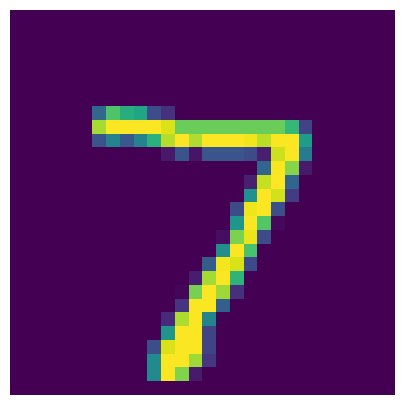

In [17]:
# 샘플 이미지 출력
import matplotlib.pylab as plt

def plot_image(data, idx):
    plt.figure(figsize=(5, 5))
    plt.imshow(data[idx])
    plt.axis("off")
    plt.show()

plot_image(x_valid, 0)

In [18]:
digit_preds, odd_preds = model.predict(x_valid_in)
print(digit_preds[0])
print(odd_preds[0])

313/313 [==============================] - 1s 2ms/step
[4.5602058e-13 9.4853889e-11 1.8399767e-08 3.3232691e-06 2.0935697e-12
 1.3874017e-12 1.2283076e-19 9.9999660e-01 2.4070982e-08 1.1253001e-08]
[0.9995271]


In [19]:
digit_labels = np.argmax(digit_preds, axis=-1)
digit_labels[0:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

In [21]:
odd_labels = (odd_preds > 0.5).astype(int).reshape(1, -1)[0]
odd_labels[0:10]

array([1, 0, 1, 0, 0, 1, 0, 1, 0, 1])

### 4. 전이 학습(Transfer Learning)

In [22]:
# 앞의 모델에서 flatten_layer 출력을 추출
base_model_output = model.get_layer('flatten_layer').output

# 앞의 출력을 출력으로 하는 모델 정의
base_model = tf.keras.models.Model(inputs=model.input, outputs=base_model_output, name='base')
base_model.summary()

Model: "base"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputs (InputLayer)         [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_layer (Conv2D)       (None, 26, 26, 32)        320       
                                                                 
 maxpool_layer (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 flatten_layer (Flatten)     (None, 5408)              0         
                                                                 
Total params: 320 (1.25 KB)
Trainable params: 320 (1.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


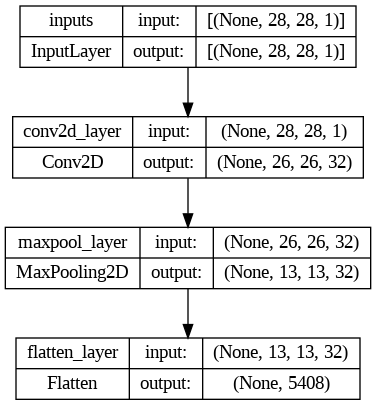

In [23]:
plot_model(base_model, show_shapes=True, show_layer_names=True, to_file='base_model.png')

In [24]:
# Sequential API 적용
digit_model = tf.keras.Sequential([
                                   base_model,
                                   tf.keras.layers.Dense(10, activation='softmax'),
                                   ])
digit_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 base (Functional)           (None, 5408)              320       
                                                                 
 dense_1 (Dense)             (None, 10)                54090     
                                                                 
Total params: 54410 (212.54 KB)
Trainable params: 54410 (212.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


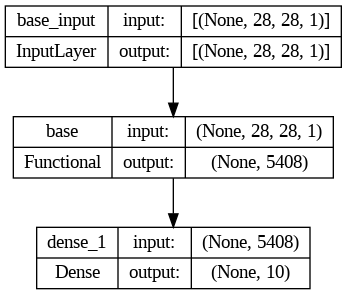

In [25]:
plot_model(digit_model, show_shapes=True, show_layer_names=True, to_file='digit_model.png')

In [26]:
# 모델 컴파일
digit_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
history = digit_model.fit(x_train_in, y_train,
                    validation_data=(x_valid_in, y_valid),
                    epochs=10)

Epoch 1/10
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1291 - accuracy: 0.9637 - val_loss: 0.0638 - val_accuracy: 0.9804
Epoch 2/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0581 - accuracy: 0.9827 - val_loss: 0.0594 - val_accuracy: 0.9817
Epoch 3/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0451 - accuracy: 0.9863 - val_loss: 0.0561 - val_accuracy: 0.9832
Epoch 4/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0362 - accuracy: 0.9888 - val_loss: 0.0522 - val_accuracy: 0.9833
Epoch 5/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0293 - accuracy: 0.9908 - val_loss: 0.0513 - val_accuracy: 0.9839
Epoch 6/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0247 - accuracy: 0.9925 - val_loss: 0.0515 - val_accuracy: 0.9836
Epoch 7/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0199 - accuracy: 0.9937 - val_loss: 0.0575 - val_accuracy

In [27]:
# 베이스 모델의 가중치를 고정 (Freeze Model)

base_model_frozen = tf.keras.models.Model(inputs=model.input, outputs=base_model_output, name='base_frozen')
base_model_frozen.trainable = False
base_model_frozen.summary()

Model: "base_frozen"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputs (InputLayer)         [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_layer (Conv2D)       (None, 26, 26, 32)        320       
                                                                 
 maxpool_layer (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 flatten_layer (Flatten)     (None, 5408)              0         
                                                                 
Total params: 320 (1.25 KB)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 320 (1.25 KB)
_________________________________________________________________


In [28]:
# Functional API 적용
dense_output = tf.keras.layers.Dense(10, activation='softmax')(base_model_frozen.output)
digit_model_frozen = tf.keras.models.Model(inputs=base_model_frozen.input, outputs=dense_output)
digit_model_frozen.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputs (InputLayer)         [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_layer (Conv2D)       (None, 26, 26, 32)        320       
                                                                 
 maxpool_layer (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 flatten_layer (Flatten)     (None, 5408)              0         
                                                                 
 dense_2 (Dense)             (None, 10)                54090     
                                                                 
Total params: 54410 (212.54 KB)
Trainable params: 54090 (211.29 KB)
Non-trainable params: 320 (1.25 KB)
_____________________

In [29]:
# 모델 컴파일
digit_model_frozen.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
history = digit_model_frozen.fit(x_train_in, y_train,
                    validation_data=(x_valid_in, y_valid),
                    epochs=10)

Epoch 1/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1159 - accuracy: 0.9682 - val_loss: 0.0594 - val_accuracy: 0.9821
Epoch 2/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0502 - accuracy: 0.9849 - val_loss: 0.0576 - val_accuracy: 0.9802
Epoch 3/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0365 - accuracy: 0.9893 - val_loss: 0.0544 - val_accuracy: 0.9826
Epoch 4/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0292 - accuracy: 0.9911 - val_loss: 0.0549 - val_accuracy: 0.9832
Epoch 5/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0235 - accuracy: 0.9930 - val_loss: 0.0532 - val_accuracy: 0.9838
Epoch 6/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0189 - accuracy: 0.9942 - val_loss: 0.0512 - val_accuracy: 0.9834
Epoch 7/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0159 - accuracy: 0.9949 - val_loss: 0.0634 - val_accuracy:

In [30]:
# 베이스 모델의 Conv2D 레이어의 가중치만 고정 (Freeze Layer)
base_model_frozen2 = tf.keras.models.Model(inputs=model.input, outputs=base_model_output, name='base_frozen2')
base_model_frozen2.get_layer('conv2d_layer').trainable = False
base_model_frozen2.summary()

Model: "base_frozen2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputs (InputLayer)         [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_layer (Conv2D)       (None, 26, 26, 32)        320       
                                                                 
 maxpool_layer (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 flatten_layer (Flatten)     (None, 5408)              0         
                                                                 
Total params: 320 (1.25 KB)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 320 (1.25 KB)
_________________________________________________________________


In [31]:
# Functional API 적용
dense_output2 = tf.keras.layers.Dense(10, activation='softmax')(base_model_frozen2.output)
digit_model_frozen2 = tf.keras.models.Model(inputs=base_model_frozen2.input, outputs=dense_output2)
digit_model_frozen2.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputs (InputLayer)         [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_layer (Conv2D)       (None, 26, 26, 32)        320       
                                                                 
 maxpool_layer (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 flatten_layer (Flatten)     (None, 5408)              0         
                                                                 
 dense_3 (Dense)             (None, 10)                54090     
                                                                 
Total params: 54410 (212.54 KB)
Trainable params: 54090 (211.29 KB)
Non-trainable params: 320 (1.25 KB)
_____________________

In [32]:
# 모델 컴파일
digit_model_frozen2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
history = digit_model_frozen2.fit(x_train_in, y_train,
                    validation_data=(x_valid_in, y_valid),
                    epochs=10)

Epoch 1/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.1160 - accuracy: 0.9681 - val_loss: 0.0585 - val_accuracy: 0.9806
Epoch 2/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0497 - accuracy: 0.9855 - val_loss: 0.0495 - val_accuracy: 0.9832
Epoch 3/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0373 - accuracy: 0.9887 - val_loss: 0.0515 - val_accuracy: 0.9840
Epoch 4/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0289 - accuracy: 0.9914 - val_loss: 0.0560 - val_accuracy: 0.9831
Epoch 5/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0232 - accuracy: 0.9929 - val_loss: 0.0484 - val_accuracy: 0.9853
Epoch 6/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0190 - accuracy: 0.9944 - val_loss: 0.0566 - val_accuracy: 0.9838
Epoch 7/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0157 - accuracy: 0.9951 - val_loss: 0.0569 - val_accuracy: